In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path
import re

import statsmodels.api as sm
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.dpi": 300
})

In [2]:
INPUT_DIR = Path("../data/dependency_analysis/input_data/")

In [3]:
OUT_DIR = Path("../data/dependency_analysis/results/proliferation_corr/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load data and pre-process

### Clean data

In [4]:
confounders_info = pd.read_csv(INPUT_DIR / "confounders_info.csv", index_col=0)
dependency_df     = pd.read_csv(INPUT_DIR / "CRISPRGeneDependency_processed.csv", index_col=0)
tca_metrics_ccle  = pd.read_csv(INPUT_DIR / "tca_metrics.csv", index_col=0)

In [5]:
# Convert columns to appropriate types and handle missing values
confounders_info["Proliferation_Score"] = pd.to_numeric(confounders_info["Proliferation_Score"], errors="coerce")
confounders_info["TP53_missing"] = confounders_info["TP53"].isna().astype(int)

# Convert TP53 to numeric and handle missing values
confounders_info["TP53"] = pd.to_numeric(confounders_info["TP53"], errors="coerce")

# Check missing TP53
n_missing = confounders_info["TP53"].isna().sum()
print(f"Linee missing TP53: {n_missing}")

confounders_info = confounders_info.dropna(subset=["TP53"]).copy()
confounders_info["TP53"] = confounders_info["TP53"].astype(int)

confounders_info["Histology"] = confounders_info["Histology"].astype(str)

tca_metrics_ccle = tca_metrics_ccle.replace([np.inf, -np.inf], np.nan).dropna(subset=["Propensity", "Flux Intensity"])
tca_metrics_ccle["Propensity"] = pd.to_numeric(tca_metrics_ccle["Propensity"], errors="coerce")
tca_metrics_ccle["Flux Intensity"] = pd.to_numeric(tca_metrics_ccle["Flux Intensity"], errors="coerce")
tca_metrics_ccle = tca_metrics_ccle.dropna(subset=["Propensity", "Flux Intensity"])

dependency_df = dependency_df.apply(pd.to_numeric, errors="coerce")

Linee missing TP53: 42


In [6]:
common_idx = sorted(set(confounders_info.index) & set(dependency_df.index) & set(tca_metrics_ccle.index))
confounders_filtered = confounders_info.loc[common_idx].copy()
dependency_df = dependency_df.loc[common_idx].copy()
tca_metrics_ccle = tca_metrics_ccle.loc[common_idx].copy()

print(f"Common cell lines (before filtering): {len(common_idx)}")

Common cell lines (before filtering): 322


In [7]:
# Filter cell lines with less than 5 samples per histology
hist_counts = confounders_filtered["Histology"].value_counts()
keep_hist = hist_counts[hist_counts >= 5].index
mask_hist = confounders_filtered["Histology"].isin(keep_hist)

confounders_filtered = confounders_filtered.loc[mask_hist].copy()
dependency_df = dependency_df.loc[mask_hist].copy()
tca_metrics_ccle = tca_metrics_ccle.loc[mask_hist].copy()

print(f"confounders filtered shape: {confounders_filtered.shape}")
print(f"classes kept: {len(keep_hist)}")

confounders filtered shape: (303, 4)
classes kept: 17


In [8]:
print(confounders_filtered["Histology"].value_counts().describe())
assert (confounders_filtered["Histology"].value_counts() >= 5).all()

count    17.000000
mean     17.823529
std      15.593409
min       5.000000
25%       7.000000
50%      14.000000
75%      20.000000
max      65.000000
Name: count, dtype: float64


In [9]:
# Drop genes with too many NAs or constant
min_n = 0.7 * dependency_df.shape[0]  # keep genes with at least 70% of coverage
valid_counts = dependency_df.notna().sum(axis=0)
genes_keep = valid_counts[valid_counts >= min_n].index
dep2 = dependency_df[genes_keep].copy()

# drop constant genes
non_const = dep2.nunique(dropna=True) > 1
dep2 = dep2.loc[:, non_const].copy()

print(f"dependency original shape: {dependency_df.shape} -> filtered: {dep2.shape}")
dependency_df = dep2.copy()

dependency original shape: (303, 18435) -> filtered: (303, 17782)


In [10]:
print("common cell lines (after filtering):", dependency_df.shape[0])

common cell lines (after filtering): 303


## Partial Correlation

### Compute residuals

In [200]:
C = pd.get_dummies(
    confounders_filtered[["Proliferation_Score", "TP53", "Histology"]],
    columns=["Histology"], prefix="lin", drop_first=True
)

# add confounders
C = sm.add_constant(C, has_constant="add")

assert C.index.equals(tca_metrics_ccle.index)
assert C.index.equals(dependency_df.index)

In [201]:
# Ensure all confounder columns are numeric float64
C = C.apply(pd.to_numeric, errors="coerce")
C = C.astype(float)

print("Non-numeric columns:", C.select_dtypes(exclude=[np.number]).columns.tolist())
print("Any NA in C:", C.isna().any().any())

Non-numeric columns: []
Any NA in C: False


In [202]:
# Fit model for Propensity
y_prop = pd.to_numeric(tca_metrics_ccle["Propensity"], errors="coerce")
dfX_prop = pd.concat([y_prop, C], axis=1).dropna()

# Fit OLS: y = C * beta + e
fitX_prop = sm.OLS(dfX_prop.iloc[:, 0].values, dfX_prop.iloc[:, 1:].values).fit()

# Residuals = observed - fitted
rX_prop = pd.Series(
    dfX_prop.iloc[:, 0].values - fitX_prop.fittedvalues,
    index=dfX_prop.index,
    name="rX_prop"
)

In [203]:
# Fit model for Flux Intensity
y_flux = pd.to_numeric(tca_metrics_ccle["Flux Intensity"], errors="coerce")

dfX_flux = pd.concat([y_flux, C], axis=1).dropna()
fitX_flux = sm.OLS(dfX_flux.iloc[:, 0].values, dfX_flux.iloc[:, 1:].values).fit()

rX_flux = pd.Series(
    dfX_flux.iloc[:, 0].values - fitX_flux.fittedvalues,
    index=dfX_flux.index,
    name="rX_flux"
)

In [204]:
# Quick sanity checks
print("Residualized X ready:",
      f"n_prop={rX_prop.notna().sum()}",
      f"n_flux={rX_flux.notna().sum()}")

# Residual sums should be ~0 if intercept is in C
print("sum(rX_prop) ~ 0:", float(rX_prop.sum()))
print("sum(rX_flux) ~ 0:", float(rX_flux.sum()))

Residualized X ready: n_prop=303 n_flux=303
sum(rX_prop) ~ 0: 7.161715664949497e-12
sum(rX_flux) ~ 0: 1.8665868850575862e-10


### Compute correlation

In [205]:
rows_prop, rows_flux = [], [] # collect (gene, rho, p, n)
min_n_gene = 50

dep_mat = dependency_df.apply(pd.to_numeric, errors="coerce")

for gene in dep_mat.columns:
    # Residualize Y_g on C: fit OLS Y_g ~ C and get residuals rY
    y_g = dep_mat[gene]
    dfY = pd.concat([y_g, C], axis=1).dropna()
    if dfY.shape[0] < min_n_gene:
        continue  # skip genes with too few samples

    fitY = sm.OLS(dfY.iloc[:, 0].values, dfY.iloc[:, 1:].values).fit()
    rY = pd.Series(
        dfY.iloc[:, 0].values - fitY.fittedvalues,
        index=dfY.index,
        name="rY"
    )

    # Spearman between residuals for Propensity
    df_xy_prop = pd.concat([rX_prop, rY], axis=1, join="inner").dropna()
    if df_xy_prop.shape[0] >= min_n_gene:
        rho, p = spearmanr(df_xy_prop.iloc[:, 0], df_xy_prop.iloc[:, 1])
        rows_prop.append((gene, rho, p, df_xy_prop.shape[0]))

    # Spearman between residuals for Flux Intensity
    df_xy_flux = pd.concat([rX_flux, rY], axis=1, join="inner").dropna()
    if df_xy_flux.shape[0] >= min_n_gene:
        rho2, p2 = spearmanr(df_xy_flux.iloc[:, 0], df_xy_flux.iloc[:, 1])
        rows_flux.append((gene, rho2, p2, df_xy_flux.shape[0]))

print("Genes tested (Propensity):", len(rows_prop))
print("Genes tested (Flux):", len(rows_flux))

Genes tested (Propensity): 17782
Genes tested (Flux): 17782


In [206]:
# FDR correction
res_prop = pd.DataFrame(rows_prop, columns=["Gene", "rho", "p", "n"])
res_flux = pd.DataFrame(rows_flux, columns=["Gene", "rho", "p", "n"])

if not res_prop.empty:
    res_prop["q"] = multipletests(res_prop["p"].values, method="fdr_bh")[1]
    res_prop = res_prop.sort_values(["q", "p"]).reset_index(drop=True)

if not res_flux.empty:
    res_flux["q"] = multipletests(res_flux["p"].values, method="fdr_bh")[1]
    res_flux = res_flux.sort_values(["q", "p"]).reset_index(drop=True)

In [ ]:
res_prop

In [208]:
# Quick summaries
print("Propensity — tested genes:", len(res_prop))
print("Propensity — significant q<0.05:", int((res_prop.get("q", pd.Series([])) < 0.05).sum()))
print(res_prop.head(20))

print("Flux Intensity — tested genes:", len(res_flux))
print("Flux Intensity — significant q<0.05:", int((res_flux.get("q", pd.Series([])) < 0.05).sum()))
print(res_flux.head(5))

Propensity — tested genes: 17782
Propensity — significant q<0.05: 28
      Gene       rho             p    n         q
0   SLC2A1 -0.294526  1.771132e-07  303  0.003149
1    ITGAV  0.276440  1.020518e-06  303  0.009073
2   DYNLL1  0.263176  3.412936e-06  303  0.020230
3     BIVM -0.257092  5.812275e-06  303  0.023862
4     EMC1  0.255425  6.709638e-06  303  0.023862
5    GSTZ1 -0.248821  1.173698e-05  303  0.028847
6     CDS2  0.244740  1.645532e-05  303  0.028847
7    DHRS4  0.245574  1.694464e-05  300  0.028847
8    UTP25  0.244229  1.715846e-05  303  0.028847
9     WDR1  0.243226  1.862487e-05  303  0.028847
10  TCF7L2 -0.243135  1.876361e-05  303  0.028847
11  STXBP3 -0.242662  1.950088e-05  303  0.028847
12  CHMP4B  0.241671  2.113375e-05  303  0.028847
13    EXT2  0.240781  2.271142e-05  303  0.028847
14   XRCC2  0.237087  3.052895e-05  303  0.034115
15   XYLT2  0.236889  3.101271e-05  303  0.034115
16   UBE2C  0.236253  3.261457e-05  303  0.034115
17    DPH3  0.233003  4.210579e

In [ ]:
# res_flux.to_csv(OUT_DIR / "sensitivity_analysis_flux_intensity.csv", index=False)
# res_prop.to_csv(OUT_DIR / "sensitivity_analysis_propensity.csv", index=False)

In [ ]:
# rX_df = pd.concat([rX_prop, rX_flux], axis=1)
# rX_df.columns = ["Propensity_resid", "Flux_resid"]
# rX_df.to_csv("../data/dependency_analysis/results/proliferation_corr/residuals_X.csv", index=True)

In [ ]:
# residual_list = []

# min_n_gene = 50
# dep_mat = dependency_df.apply(pd.to_numeric, errors="coerce")

# for gene in dep_mat.columns:
#     y_g = dep_mat[gene]
#     dfY = pd.concat([y_g, C], axis=1).dropna()

#     if dfY.shape[0] < min_n_gene:
#         continue

#     # Fit OLS: Y_g ~ confounders
#     fitY = sm.OLS(dfY.iloc[:, 0].values, dfY.iloc[:, 1:].values).fit()
#     rY = pd.Series(
#         dfY.iloc[:, 0].values - fitY.fittedvalues,
#         index=dfY.index,
#         name=gene
#     )

#     residual_list.append(rY)

# residY = pd.concat(residual_list, axis=1)
# residY.to_csv("../data/dependency_analysis/results/proliferation_corr/residuals_CERES.csv")

In [4]:
res_flux = pd.read_csv(OUT_DIR / "sensitivity_analysis_flux_intensity.csv")
res_prop = pd.read_csv(OUT_DIR / "sensitivity_analysis_propensity.csv")

In [5]:
rX_prop = pd.read_csv("../data/dependency_analysis/results/proliferation_corr/residuals_X.csv", index_col=0)["Propensity_resid"]
rX_flux = pd.read_csv("../data/dependency_analysis/results/proliferation_corr/residuals_X.csv", index_col=0)["Flux_resid"]
dependency_df = pd.read_csv("../data/dependency_analysis/results/proliferation_corr/residuals_CERES.csv", index_col=0)

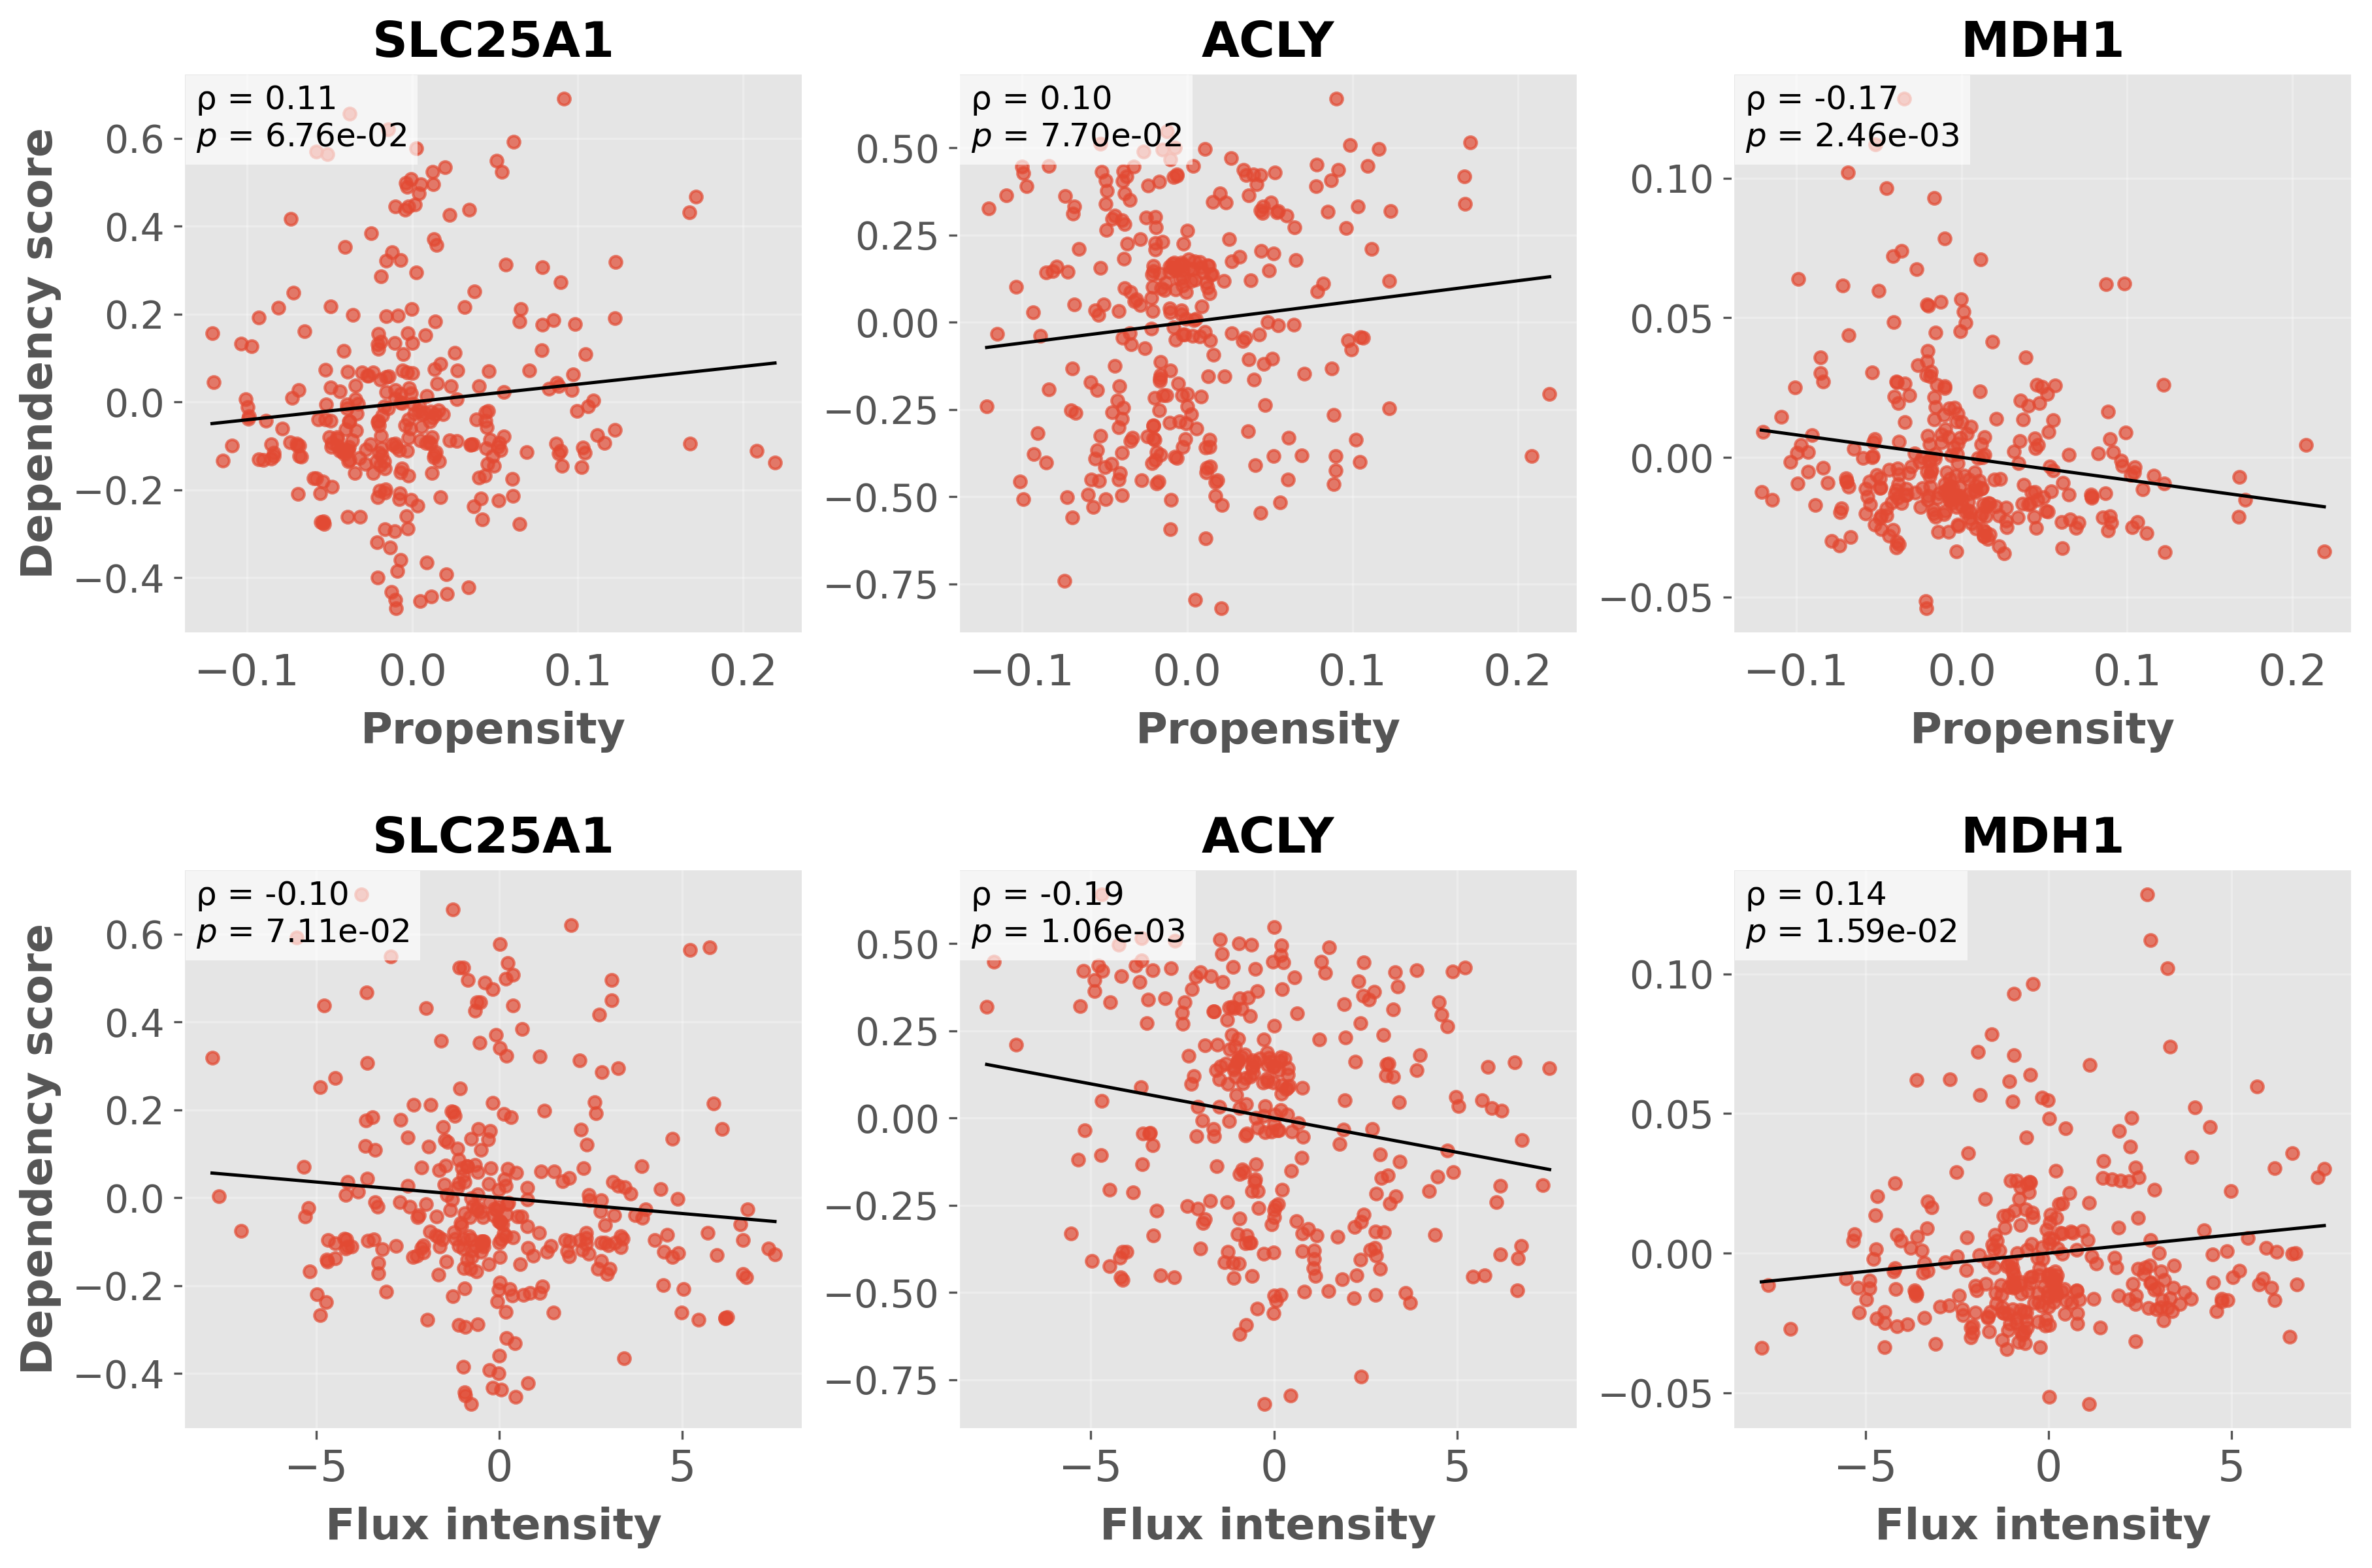

In [7]:
genes_cycle = ["SLC25A1", "ACLY", "MDH1"]

def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

def plot_dep_scatter_grid(
    metrics,                 # [(xlab, resid_series), ...]
    dependency_df,           # CERES residuals (index=cell lines, columns=genes)
    genes,               
    outfile=None
):
    nrows = len(metrics)
    ncols = len(genes)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.1, hspace=0.08, wspace=0.02)


    for i, (xlab, resid_series) in enumerate(metrics):
        resid = resid_series.rename(xlab)
        for j, gene in enumerate(genes):
            ax = axes[i, j]

            dfp = pd.concat([resid, dependency_df[gene]], axis=1, join="inner").dropna()
            dfp.columns = [xlab, "Dependency score"]

            rho, p = spearmanr(dfp[xlab], dfp["Dependency score"])

            sns.regplot(
                x=xlab, y="Dependency score", data=dfp, ax=ax,
                ci=None,
                scatter_kws=dict(s=20, alpha=0.7),
                line_kws=dict(lw=1.2, color="black")
            )

            ax.set_xlim(*_pad(dfp[xlab].min(), dfp[xlab].max()))
            ax.set_ylim(*_pad(dfp["Dependency score"].min(), dfp["Dependency score"].max()))

            ax.set_title(gene, fontweight='bold')

            if j == 0:
                ax.set_ylabel("Dependency score", fontsize=16, fontweight='bold')
            else:
                ax.set_ylabel("")

            if i == nrows - 1:
                ax.set_xlabel(xlab, fontsize=16, fontweight='bold', labelpad=6)
                ax.xaxis.set_label_position('bottom')
                ax.tick_params(axis='x', labelbottom=True, bottom=True, labeltop=False, top=False)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis='x', labelbottom=True, bottom=False, labeltop=False, top=False)

            ax.tick_params(axis='y', which='major', labelsize=14)
            ax.set_xlabel(xlab, fontsize=16, fontweight='bold', labelpad=6)

            ax.grid(True, alpha=0.3)

            ax.text(
                0.02, 0.98,
                f"ρ = {rho:.2f}\n$p$ = {p:.2e}",
                transform=ax.transAxes,
                fontsize=12,
                va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.65, edgecolor='none')
            )

    if outfile:
        fig.savefig(outfile, dpi=300)
    plt.show()

# Esempio chiamata (come prima)
metrics_list = [
    ("Propensity", rX_prop),
    ("Flux intensity", rX_flux)
]

plot_dep_scatter_grid(
    metrics=metrics_list,
    dependency_df=dependency_df,
    genes=genes_cycle,
    outfile="../data/dependency_analysis/results/proliferation_corr/plots/cycle_genes_propensity_flux_grid.png"
)


C:\Users\LL331070\AppData\Local\Temp\ipykernel_37684\3492959437.py:63: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0.02, 1, 0.98])


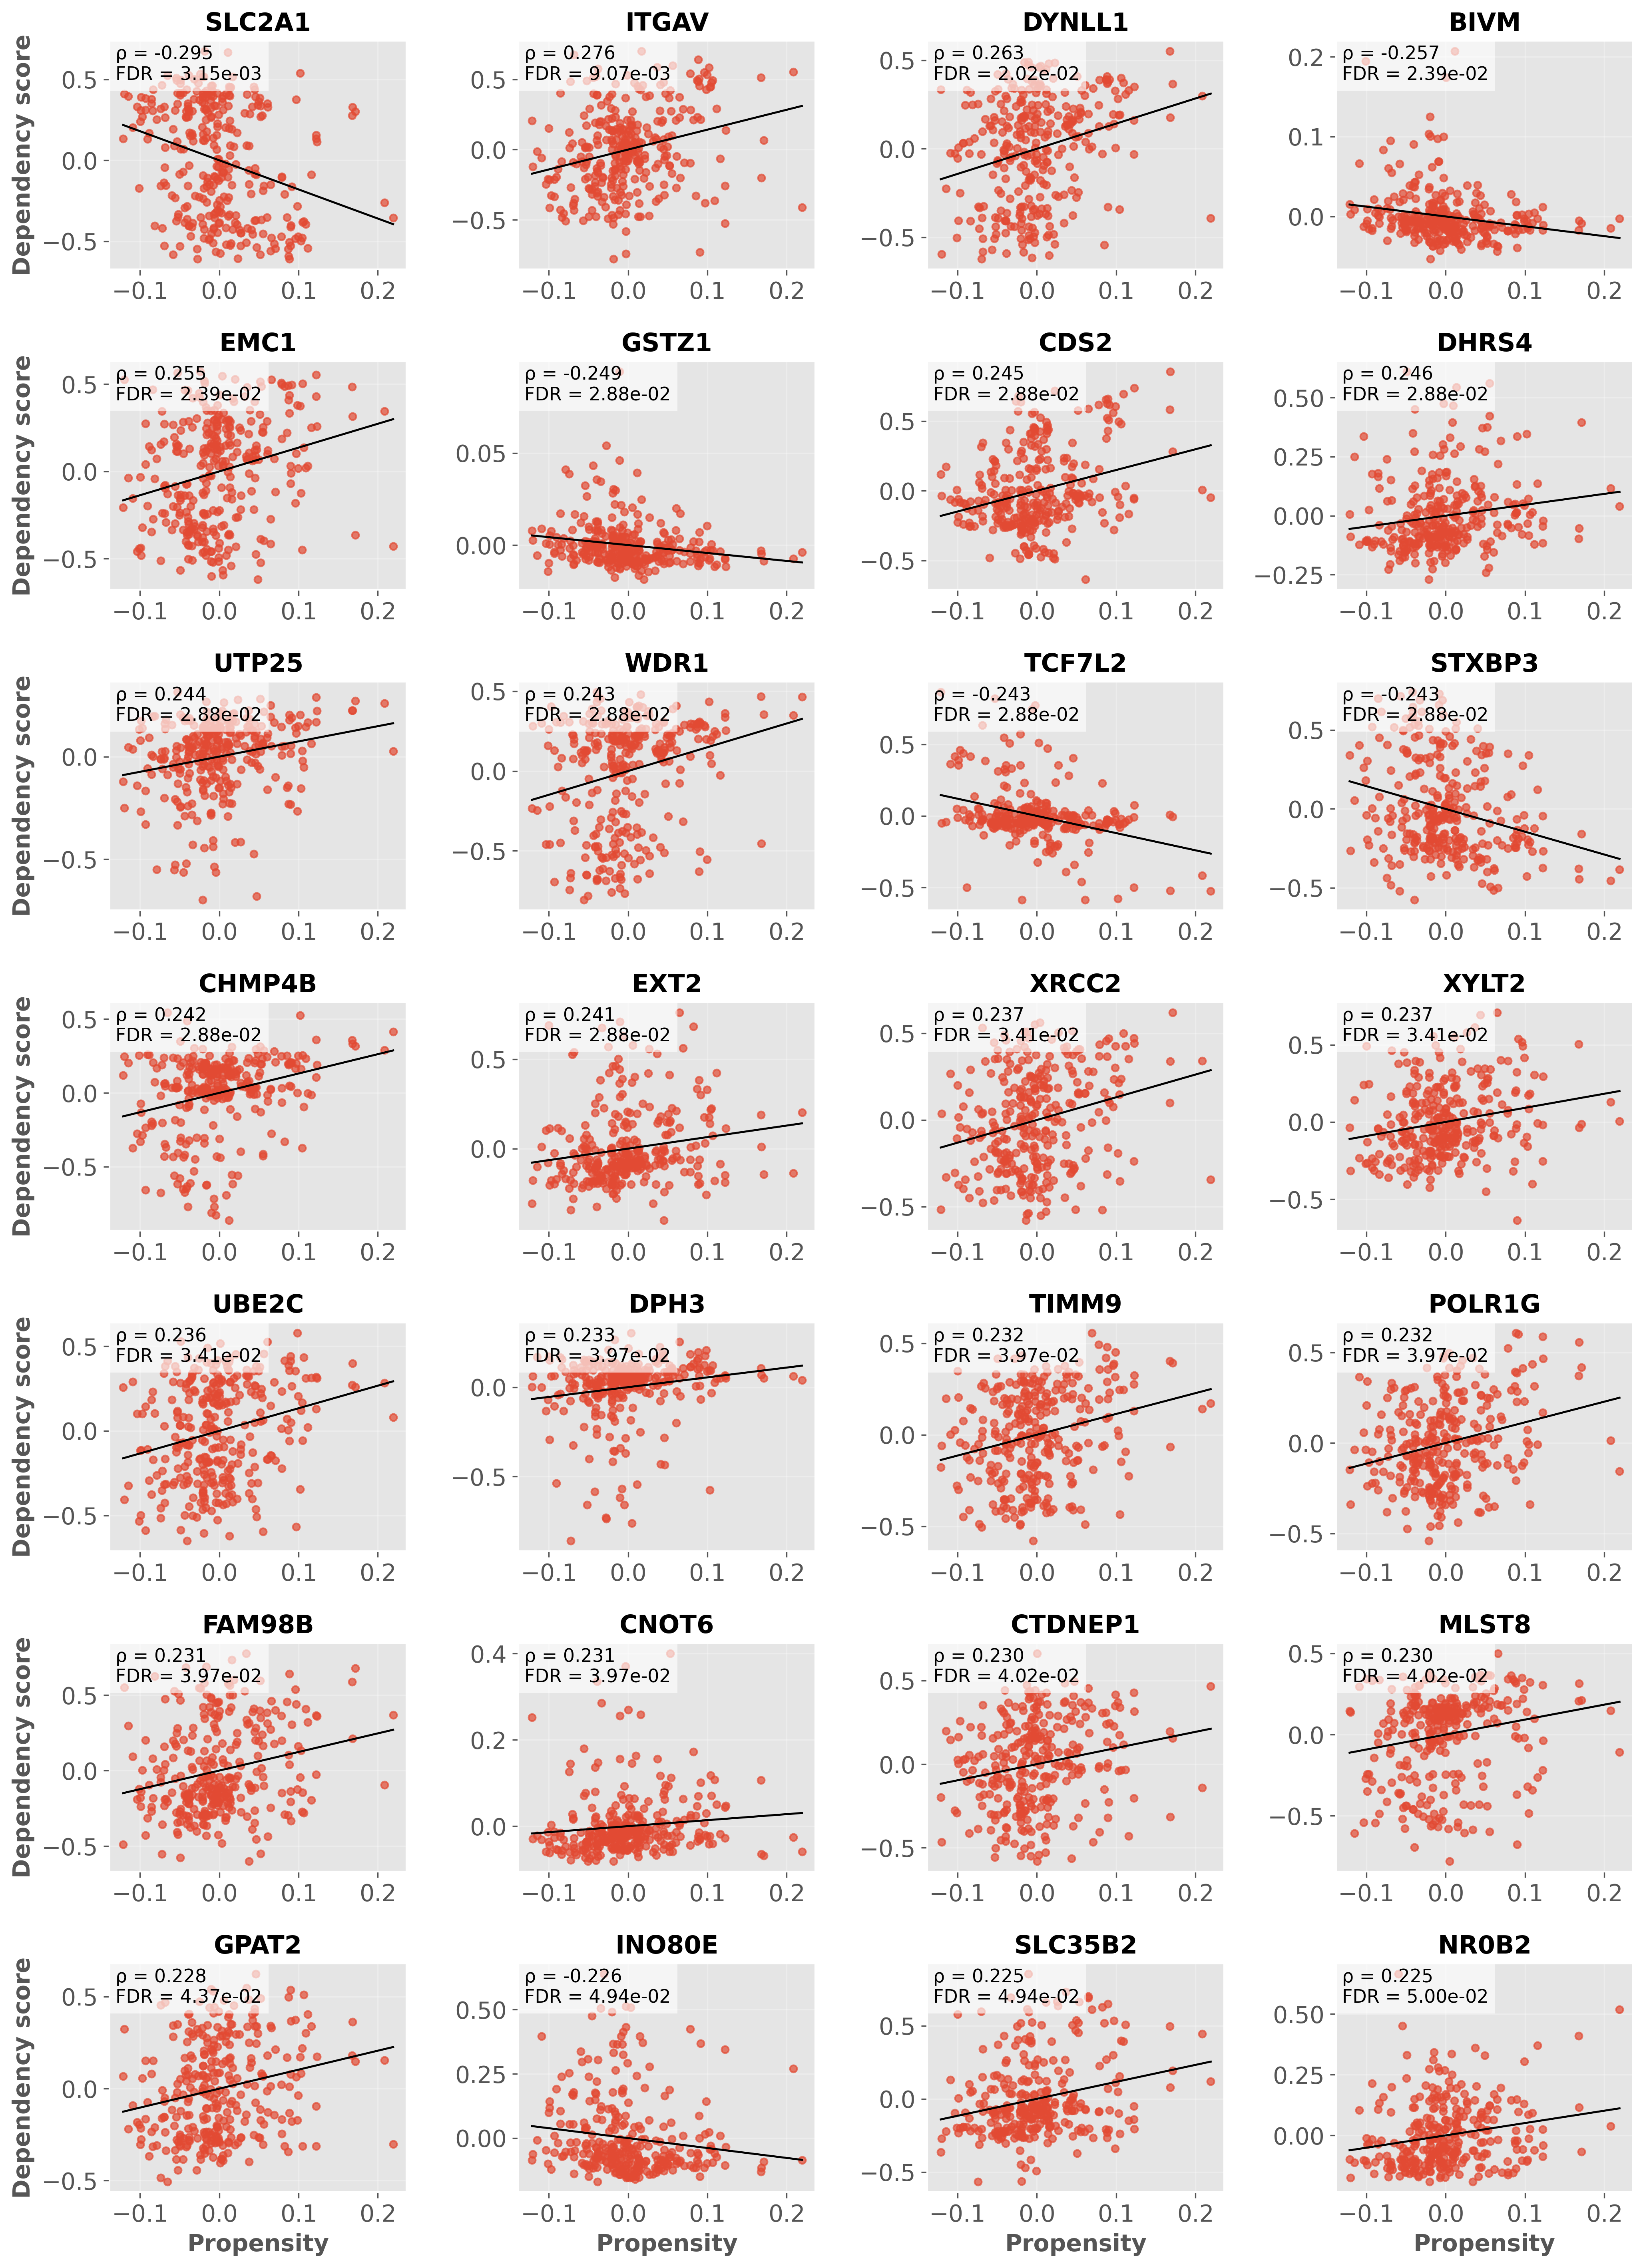

In [104]:
top_prop = res_prop.head(28).copy()

def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

n_genes = len(top_prop)
ncols = 4
nrows = math.ceil(n_genes / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 20), constrained_layout=True)
axes = axes.ravel()

for k, (_, row) in enumerate(top_prop.iterrows()):
    ax = axes[k]
    gene = row["Gene"]
    rho = row["rho"]
    p = row["p"]
    q = row.get("q", float("nan"))
    n = int(row.get("n", 0))

    dfp = pd.concat([rX_prop, dependency_df[gene]], axis=1, join="inner").dropna()
    dfp.columns = ["Propensity_resid", "Gene_value"]

    sns.regplot(
        x="Propensity_resid", y="Gene_value", data=dfp, ax=ax,
        ci=None,
        scatter_kws=dict(s=18, alpha=0.7),
        line_kws=dict(lw=1.2, color="black")
    )

    ax.set_xlim(*_pad(dfp["Propensity_resid"].min(), dfp["Propensity_resid"].max()))
    ax.set_ylim(*_pad(dfp["Gene_value"].min(), dfp["Gene_value"].max()))

    ax.set_title(gene, fontweight='bold', fontsize=15)

    if (k % ncols) == 0:
        ax.set_ylabel("Dependency score", fontsize=14, fontweight='bold')
    else:
        ax.set_ylabel("")

    if k // ncols == (nrows - 1):
        ax.set_xlabel("Propensity", fontsize=14, fontweight='bold', labelpad=4)
    else:
        ax.set_xlabel("")

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.text(
        0.02, 0.98,
        f"ρ = {rho:.3f}\nFDR = {q:.2e}",
        transform=ax.transAxes,
        fontsize=11,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.65, edgecolor='none')
    )

for ax in axes[n_genes:]:
    ax.remove()

fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.savefig("../data/dependency_analysis/results/proliferation_corr/plots/propensity_dependence_top28_4x7.png", dpi=600)
plt.show()


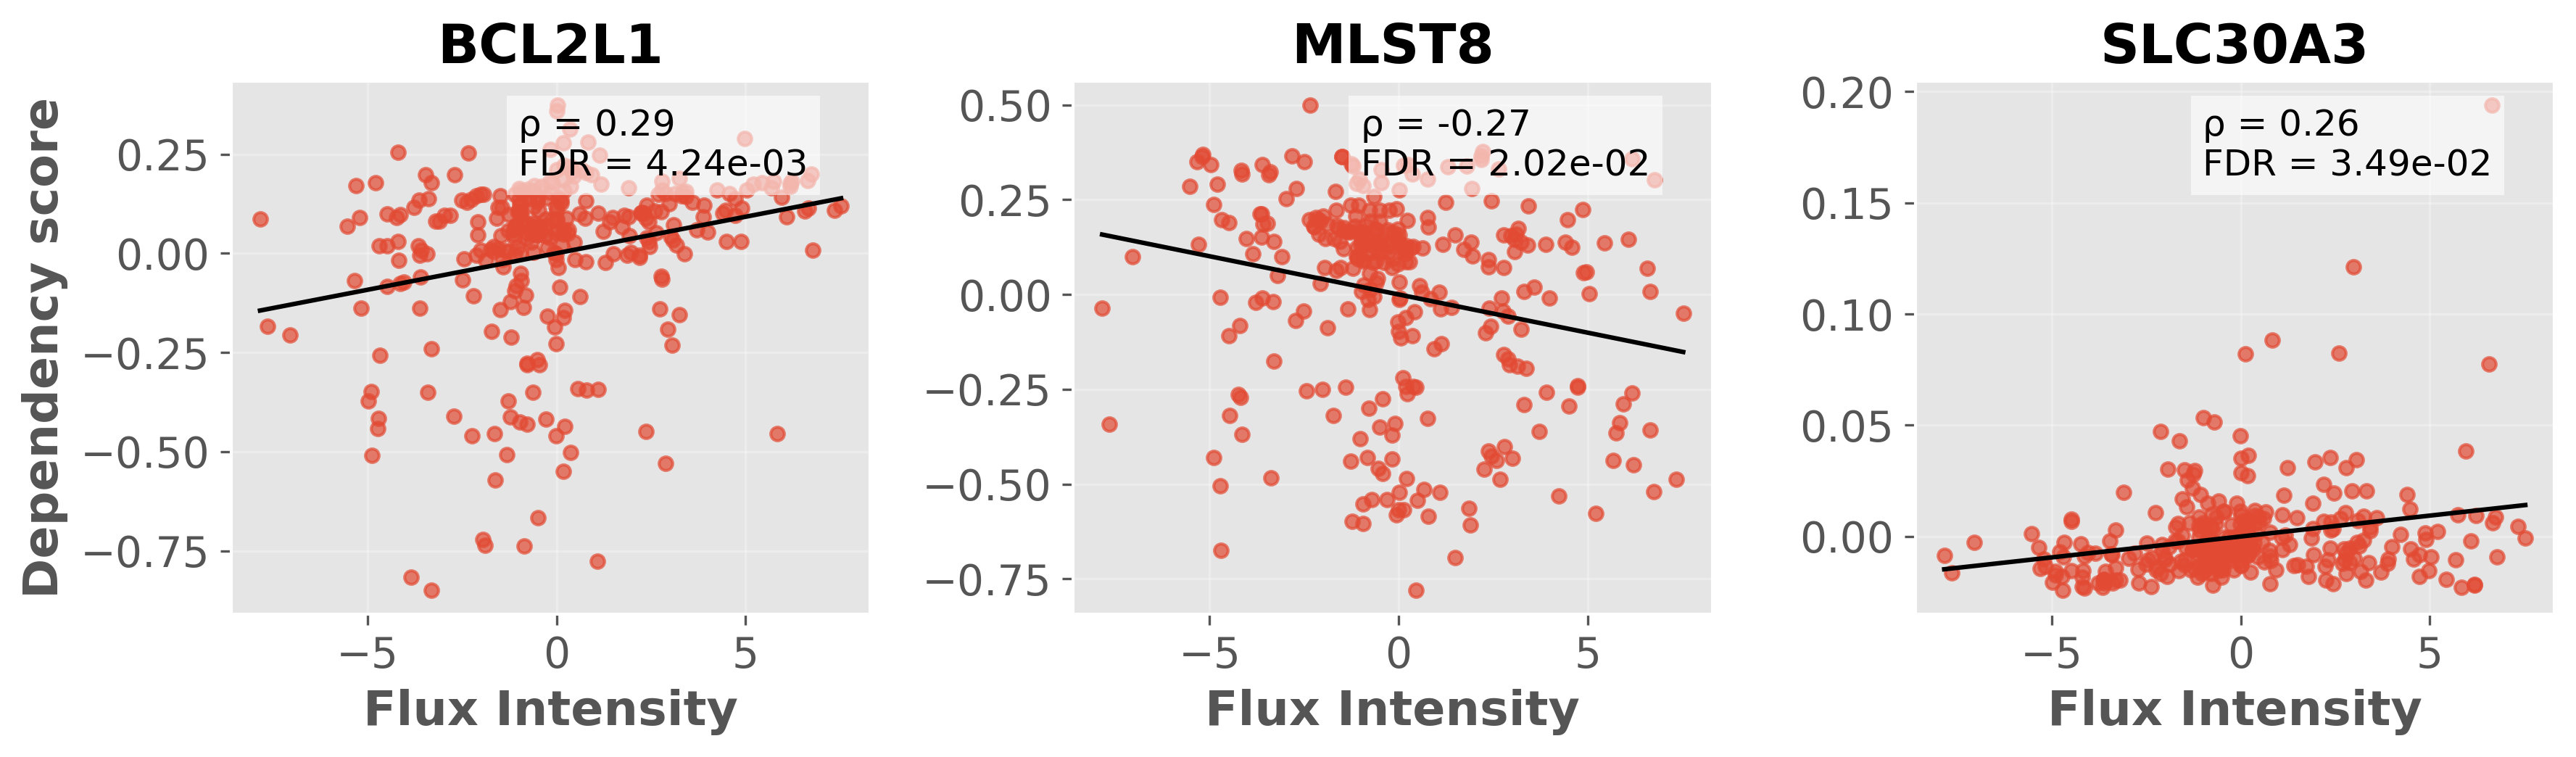

In [ ]:
top_flux = res_flux.head(3).copy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
axes = axes.ravel()

for i, (_, row) in enumerate(top_flux.iterrows()):
    gene = row["Gene"]
    rho  = row["rho"]
    p    = row["p"]
    q    = row.get("q", float("nan"))
    n    = int(row["n"])

    # Build plotting frame (Flux residuals vs gene dependency)
    dfp = pd.concat([rX_flux, dependency_df[gene]], axis=1, join="inner").dropna()
    dfp.columns = ["Flux_resid", "Gene_value"]

    sns.regplot(
        x="Flux_resid", y="Gene_value", data=dfp, ax=axes[i],
        ci=None,
        scatter_kws=dict(s=20, alpha=0.7),
        line_kws=dict(lw=1.5, color="black")
    )

    axes[i].set_xlim(*_pad(dfp["Flux_resid"].min(), dfp["Flux_resid"].max()))
    axes[i].set_ylim(*_pad(dfp["Gene_value"].min(), dfp["Gene_value"].max()))

    axes[i].set_title(gene, fontweight='bold')
    axes[i].set_xlabel("Flux Intensity", fontsize=16, fontweight='bold')

    if i == 0:
        axes[i].set_ylabel("Dependency score", fontsize=16, fontweight='bold')
    else:
        axes[i].set_ylabel("")

    axes[i].tick_params(axis='both', which='major', labelsize=14)
    axes[i].grid(True, alpha=0.3)

    axes[i].text(
        0.45, 0.95,
        f"ρ = {rho:.2f}\n"
        f"FDR = {q:.2e}",
        transform=axes[i].transAxes,
        fontsize=12,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

# If fewer than 3 genes, remove empty axes
for ax in axes[len(top_flux):]:
    ax.remove()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("../data/dependency_analysis/results/proliferation_corr/plots/flux_dependence.png", dpi=300)
plt.show()


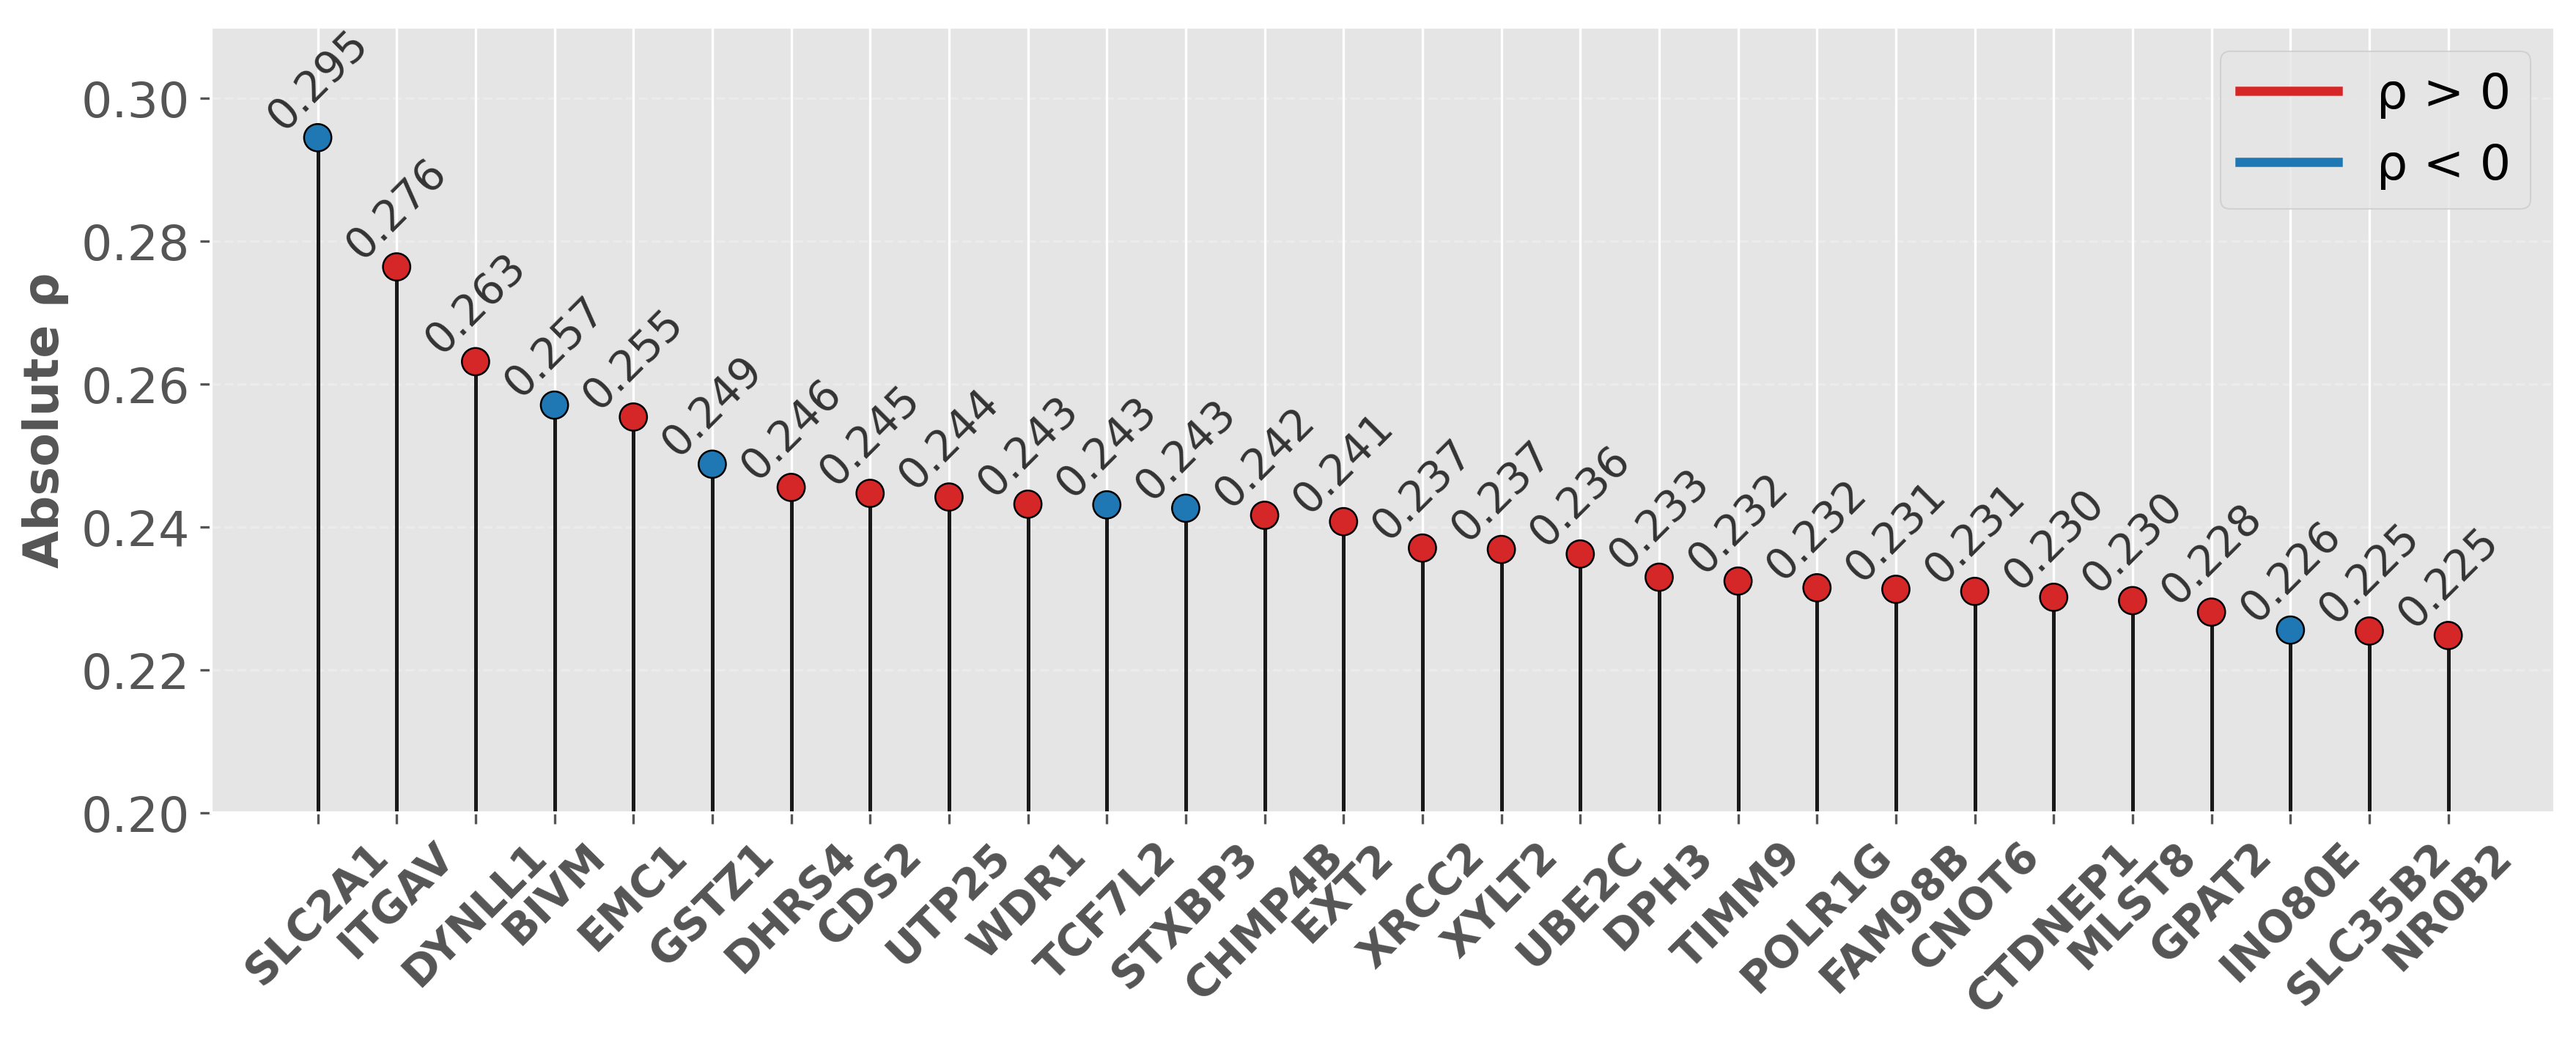

In [100]:
from matplotlib.lines import Line2D

fdr_thr = 0.05
point_size = 80
line_lw = 1.2
xlabel = "Gene"
ylabel = "Absolute ρ"
xrot = 45
outfile = "../data/dependency_analysis/results/proliferation_corr/plots/propensity_lollipop_absrho_vertical_0p2_0p3.png"

sig = res_prop.loc[res_prop["q"] < fdr_thr].copy()
if sig.empty:
    print("Nessun gene significativo a questa soglia FDR.")
else:
    sig["abs_rho"] = sig["rho"].abs()
    sig = sig.sort_values("abs_rho", ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))

    def color_for_rho(r):
        return "#d62728" if r >= 0 else "#1f77b4"   # rosso = ρ>0, blu = ρ<0

    # coordinates
    x = np.arange(len(sig)) * 1.5
    y = sig["abs_rho"].values

    # vertical line
    for xi, yi, r in zip(x, y, sig["rho"].values):
        ax.vlines(xi, 0, yi, lw=line_lw, color="black", alpha=0.9)

    # dot
    ax.scatter(x, y,
               s=point_size,
               color=[color_for_rho(r) for r in sig["rho"].values],
               edgecolor="black", linewidth=0.6, zorder=3)

    # labels
    ax.set_xticks(x)
    ax.set_xticklabels(sig["Gene"].values,
                       rotation=xrot, ha="center",
                       fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=16, fontweight="bold")

    # ylim
    ax.set_ylim(0.2, 0.31)

    # annotation
    for xi, yi, r_abs in zip(x, y, sig["abs_rho"].values):
        ax.text(xi, yi, f"{r_abs:.3f}",
                ha="center", va="bottom",
                fontsize=14, color="#333", rotation=45)

    ax.grid(axis="y", linestyle="--", alpha=0.25)

    legend_elems = [
        Line2D([0], [0], color="#d62728", lw=3, label="ρ > 0"),
        Line2D([0], [0], color="#1f77b4", lw=3, label="ρ < 0"),
    ]
    ax.legend(handles=legend_elems, loc="upper right", frameon=True, fontsize=16)

    fig.tight_layout()
    fig.savefig(outfile, dpi=600, bbox_inches="tight")
    plt.show()
